# Adult Census Income: Preprocessing (one transformation per cell)

Every cell starts from the output of the previous stage and creates a **new** dataframe (`*_1`, `*_2`, ...). Nothing is modified in place, so **any cell can be re-run any number of times** with the same result. Only the load cell touches the internet.

Each step shows **Flaw -> Correction -> Result** for the official train (`adult.data`) and test (`adult.test`) files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

URL_TRAIN = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
URL_TEST  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
COLS = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]

## Step 0: Load the raw files
`?` is read as NaN. `adult.test` has a junk first line, so it is skipped.

In [2]:
train_raw = pd.read_csv(URL_TRAIN, header=None, names=COLS, na_values="?", skipinitialspace=True)
test_raw  = pd.read_csv(URL_TEST,  header=None, names=COLS, na_values="?", skipinitialspace=True, skiprows=1)
print("train:", train_raw.shape, "| test:", test_raw.shape)
train_raw.head()

train: (32561, 15) | test: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 1: Clean the target label
**Flaw:** test labels end with a dot (`<=50K.`), so they don't match the train labels.  
**Fix:** strip the dot and map to 0/1.

In [11]:
def fix_target(df):
    out = df.copy()
    out["income"] = out["income"].astype(str).str.strip().str.rstrip(".").map({"<=50K": 0, ">50K": 1})
    return out

print("BEFORE  train:", sorted(train_raw["income"].unique()), "| test:", sorted(test_raw["income"].unique()))
train_1, test_1 = fix_target(train_raw), fix_target(test_raw)
print("AFTER   train:", sorted(train_1["income"].unique()), "| test:", sorted(test_1["income"].unique()))
assert train_1["income"].notna().all() and test_1["income"].notna().all()
print("Positive rate  train: %.3f | test: %.3f" % (train_1["income"].mean(), test_1["income"].mean()))

BEFORE  train: ['<=50K', '>50K'] | test: ['<=50K.', '>50K.']
AFTER   train: [np.int64(0), np.int64(1)] | test: [np.int64(0), np.int64(1)]
Positive rate  train: 0.241 | test: 0.236


## Step 2: Drop `fnlwgt` and `education`
**Flaw:** `education` is a text duplicate of `education-num` (kept because it is ordered); `fnlwgt` is a census sampling weight, not a feature of the person.

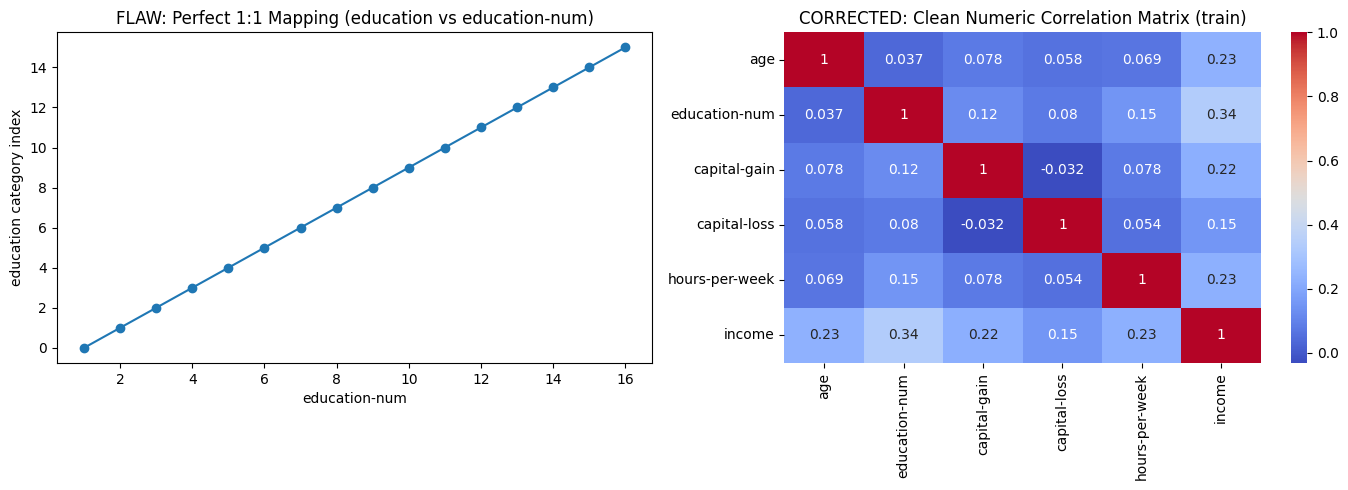

Columns left: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [12]:
def drop_cols(df):
    return df.drop(columns=["fnlwgt", "education"])

# --- 1. SHOW THE FLAW (train only) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_mapping = train_1.groupby('education-num')['education'].unique().apply(lambda x: x[0])
axes[0].plot(edu_mapping.index, range(len(edu_mapping)), marker='o', linestyle='-')
axes[0].set_title("FLAW: Perfect 1:1 Mapping (education vs education-num)")
axes[0].set_xlabel("education-num")
axes[0].set_ylabel("education category index")

# --- 2. APPLY CORRECTION (train and test) ---
train_2, test_2 = drop_cols(train_1), drop_cols(test_1)

# --- 3. SHOW THE CORRECTION (train only) ---
sns.heatmap(train_2.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("CORRECTED: Clean Numeric Correlation Matrix (train)")

plt.tight_layout()
plt.show()

print("Columns left:", list(train_2.columns))


## Step 3: Missing values
**Flaw:** `workclass`, `occupation` and `native-country` have missing values (`?`). Dropping rows loses data (and the official test rows must stay), and the mode would invent false information.
**Fix:** missing `workclass` / `occupation` become their own category, `"Unknown"`. This needs no fitting, so there is no leakage.

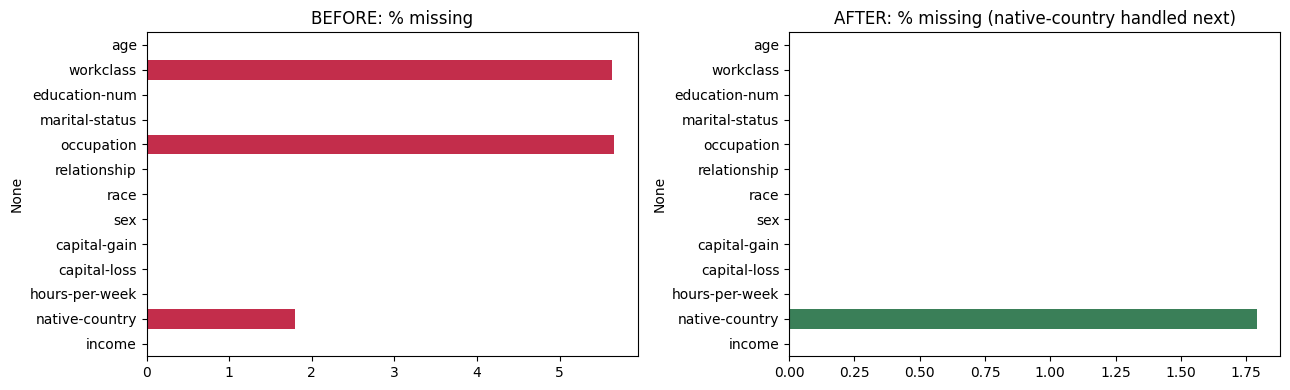

In [13]:
def fill_unknown(df):
    out = df.copy()
    for c in ["workclass", "occupation"]:
        out[c] = out[c].fillna("Unknown")
    return out

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
before = train_2.isna().mean().mul(100)
sns.barplot(x=before.values, y=before.index, ax=ax[0], color="crimson"); ax[0].set_title("BEFORE: % missing")

train_3, test_3 = fill_unknown(train_2), fill_unknown(test_2)
after = train_3.isna().mean().mul(100)
sns.barplot(x=after.values, y=after.index, ax=ax[1], color="seagreen"); ax[1].set_title("AFTER: % missing (native-country handled next)")
plt.tight_layout(); plt.show()

## Step 4: `native-country` -> US / Non-US / Unknown
**Flaw:** 41 values, about 90% are `United-States`, and it is the weakest feature by mutual information. 41 one-hot columns mostly add noise. Regional grouping needs guesses (e.g. `South`).
**Fix:** three levels: `US`, `Non-US`, `Unknown`.

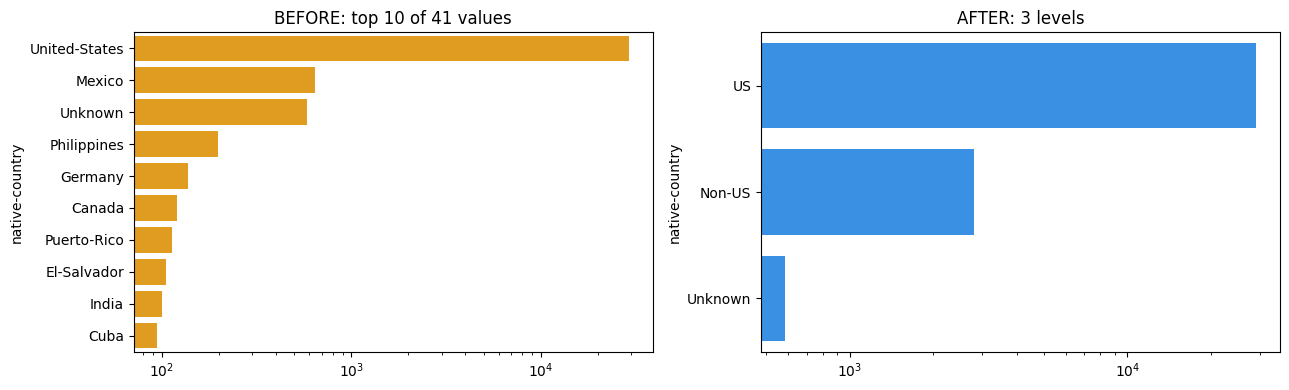

In [14]:
def group_country(df):
    out = df.copy()
    nc = out["native-country"]
    out["native-country"] = np.where(nc.isna(), "Unknown", np.where(nc == "United-States", "US", "Non-US"))
    return out

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
top = train_3["native-country"].fillna("Unknown").value_counts().head(10)
sns.barplot(x=top.values, y=top.index, ax=ax[0], color="orange"); ax[0].set_xscale("log"); ax[0].set_title("BEFORE: top 10 of %d values" % train_3["native-country"].nunique())

train_4, test_4 = group_country(train_3), group_country(test_3)
c = train_4["native-country"].value_counts()
sns.barplot(x=c.values, y=c.index, ax=ax[1], color="dodgerblue"); ax[1].set_xscale("log"); ax[1].set_title("AFTER: 3 levels")
plt.tight_layout(); plt.show()

## Step 5: Log-transform the skewed money columns
**Flaw:** `capital-gain` and `capital-loss` are about 92% zeros with a few huge values (up to 99,999). This hurts distance- and gradient-based models (k-NN, SVM, MLP, logistic regression, Naive Bayes).  
**Fix:** `log1p(x)`. It is applied once to a fresh copy, so re-running cannot double-transform.

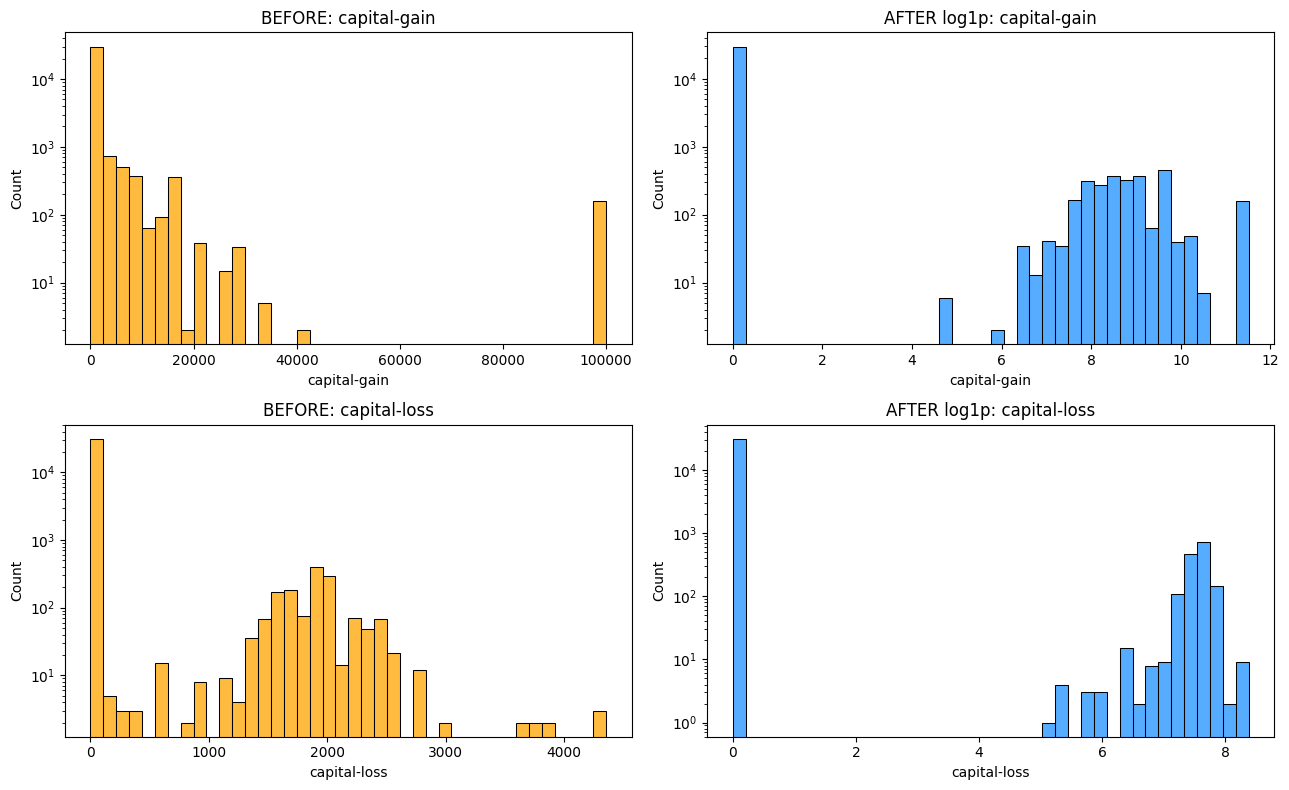

In [15]:
def log_money(df):
    out = df.copy()
    out[["capital-gain", "capital-loss"]] = np.log1p(out[["capital-gain", "capital-loss"]])
    return out

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(["capital-gain", "capital-loss"]):
    sns.histplot(train_4[col], bins=40, ax=ax[i, 0], color="orange"); ax[i, 0].set_yscale("log"); ax[i, 0].set_title("BEFORE: " + col)

train_5, test_5 = log_money(train_4), log_money(test_4)
for i, col in enumerate(["capital-gain", "capital-loss"]):
    sns.histplot(train_5[col], bins=40, ax=ax[i, 1], color="dodgerblue"); ax[i, 1].set_yscale("log"); ax[i, 1].set_title("AFTER log1p: " + col)
plt.tight_layout(); plt.show()

## Step 6: Final cleaned data and checks

In [16]:
train_clean, test_clean = train_5.copy(), test_5.copy()

assert list(train_clean.columns) == list(test_clean.columns)
assert train_clean.isna().sum().sum() == 0 and test_clean.isna().sum().sum() == 0
print("train:", train_clean.shape, "| test:", test_clean.shape)
print("Class balance  train: %.1f%% >50K | test: %.1f%% >50K" % (100*train_clean["income"].mean(), 100*test_clean["income"].mean()))
train_clean.head()

train: (32561, 13) | test: (16281, 13)
Class balance  train: 24.1% >50K | test: 23.6% >50K


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40,US,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13,US,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40,US,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40,US,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40,Non-US,0


## Step 7: Scaling and encoding (fit on TRAIN only)
These steps *learn* from data, so they are not applied here to the whole dataset. They live in a `ColumnTransformer` that is placed inside each model's `Pipeline` and fitted inside cross-validation folds, which prevents leakage. Use `scale=False` for tree-based models.

In [18]:
NUMERIC     = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAL = ["workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

def build_preprocessor(scale=True):
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ])

X_train, y_train = train_clean.drop(columns="income"), train_clean["income"]
X_test,  y_test  = test_clean.drop(columns="income"),  test_clean["income"]

# Demo only: in the real experiments this goes inside Pipeline([("prep", ...), ("clf", ...)])
prep = build_preprocessor().fit(X_train)
print("Encoded features:", prep.transform(X_train).shape[1], "| test shape:", prep.transform(X_test).shape)

Encoded features: 52 | test shape: (16281, 52)


## Not applied on purpose: SMOTE / resampling
The classes are 76/24, which is mild. Resampling would lower accuracy relative to the published benchmarks, so the main results use the real distribution (optionally `class_weight="balanced"`). If you want a comparison, do SMOTENC **inside** the CV folds only, never on the full data.

## Step 8: Baseline model, run end-to-end
Sanity check that the pipeline actually works: fit a plain `LogisticRegression` on the preprocessed train split, predict on the held-out official test split, and look at the metrics. This is a baseline, not the final model — it just proves the preprocessing -> model -> evaluation path runs cleanly.


Accuracy: 0.802 | ROC-AUC: 0.899
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86     12435
        >50K       0.55      0.84      0.67      3846

    accuracy                           0.80     16281
   macro avg       0.75      0.81      0.76     16281
weighted avg       0.85      0.80      0.81     16281



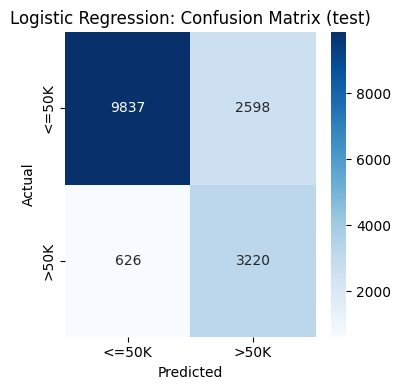

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

clf = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy: %.3f | ROC-AUC: %.3f" % (accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)))
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Logistic Regression: Confusion Matrix (test)")
plt.tight_layout()
plt.show()


---
# Part 2: Algorithm Experiments & Sensitivity Analysis

Each section below follows the same pattern:
1. **Define** a hyperparameter grid.
2. **Tune** via 5-fold stratified cross-validation on the training set only.
3. **Plot** the sensitivity curve (how CV accuracy changes with the key hyperparameter).
4. **Evaluate** the best configuration once on the official test set.

All models use the same `build_preprocessor()` from Step 7 inside a `Pipeline`, so scaling and encoding are fitted per fold with no leakage.

In [20]:
# Shared imports for all algorithms
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Collector for the final comparison table
results = []

def evaluate_and_store(name, grid, X_tr, y_tr, X_te, y_te):
    """Run grid search, plot sensitivity, evaluate on test, store results."""
    grid.fit(X_tr, y_tr)

    # ── sensitivity table ──
    cv_df = pd.DataFrame(grid.cv_results_)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"Best params : {grid.best_params_}")
    print(f"Best CV acc : {grid.best_score_:.4f}")

    # ── test evaluation ──
    best = grid.best_estimator_
    y_pred = best.predict(X_te)
    y_prob = best.predict_proba(X_te)[:, 1] if hasattr(best, "predict_proba") else best.decision_function(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    print(f"\nTest accuracy : {acc:.4f}")
    print(f"Test ROC-AUC  : {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=["<=50K", ">50K"]))

    results.append({"Algorithm": name, "Best CV Accuracy": grid.best_score_,
                     "Test Accuracy": acc, "Precision": prec, "Recall": rec,
                     "F1": f1, "ROC-AUC": auc, "Best Params": str(grid.best_params_)})
    return grid, cv_df

## Algorithm 1: Logistic Regression
A linear model that predicts the log-odds of the positive class. We tune:
- **C** — inverse regularisation strength (small C = strong penalty, large C = weak penalty)
- **penalty** — L1 (sparse features) vs L2 (shrinkage)

c:\Users\Harshit  Jain\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



  Logistic Regression
Best params : {'clf__C': 1, 'clf__penalty': 'l2'}
Best CV acc : 0.8448

Test accuracy : 0.8474
Test ROC-AUC  : 0.8987
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     12435
        >50K       0.71      0.59      0.65      3846

    accuracy                           0.85     16281
   macro avg       0.80      0.76      0.77     16281
weighted avg       0.84      0.85      0.84     16281



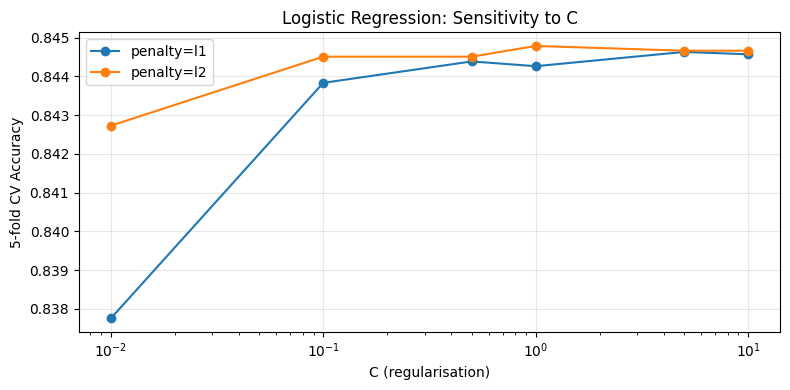

In [21]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("clf",  LogisticRegression(max_iter=1000, solver="saga", random_state=42))
])

param_grid_lr = {
    "clf__C":       [0.01, 0.1, 0.5, 1, 5, 10],
    "clf__penalty": ["l1", "l2"],
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=CV, scoring="accuracy",
                       n_jobs=-1, return_train_score=True)
gs_lr, cv_lr = evaluate_and_store("Logistic Regression", grid_lr,
                                   X_train, y_train, X_test, y_test)

# Sensitivity plot: accuracy vs C for each penalty
fig, ax = plt.subplots(figsize=(8, 4))
for pen in ["l1", "l2"]:
    mask = cv_lr["param_clf__penalty"] == pen
    ax.plot(cv_lr.loc[mask, "param_clf__C"].astype(float),
            cv_lr.loc[mask, "mean_test_score"], "o-", label=f"penalty={pen}")
ax.set_xscale("log"); ax.set_xlabel("C (regularisation)"); ax.set_ylabel("5-fold CV Accuracy")
ax.set_title("Logistic Regression: Sensitivity to C"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 2: Naive Bayes (Multinomial)
A probabilistic classifier that assumes feature independence. We use MultinomialNB (requires non-negative features) with MinMaxScaler instead of StandardScaler. We tune:
- **alpha** — Laplace smoothing parameter (0 = no smoothing, larger = more smoothing)

*Published baseline (Kohavi 1996): ~83.88% accuracy on this dataset.*

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

def build_preprocessor_nb():
    """MinMaxScaler for non-negative features required by MultinomialNB."""
    return ColumnTransformer([
        ("num", MinMaxScaler(), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ])

pipe_nb = Pipeline([
    ("prep", build_preprocessor_nb()),
    ("clf",  MultinomialNB())
])

param_grid_nb = {
    "clf__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
}

grid_nb = GridSearchCV(pipe_nb, param_grid_nb, cv=CV, scoring="accuracy",
                       n_jobs=-1, return_train_score=True)
gs_nb, cv_nb = evaluate_and_store("Naive Bayes", grid_nb,
                                   X_train, y_train, X_test, y_test)

# Sensitivity plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cv_nb["param_clf__alpha"].astype(float), cv_nb["mean_test_score"], "o-", color="darkorange")
ax.set_xscale("log"); ax.set_xlabel("alpha (smoothing)"); ax.set_ylabel("5-fold CV Accuracy")
ax.set_title("Naive Bayes: Sensitivity to alpha"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 3: k-Nearest Neighbours (k-NN)
An instance-based learner: classify by majority vote of the k closest training points. We tune:
- **n_neighbors** (k) — the classic bias-variance knob (small k = overfit, large k = underfit)
- **weights** — uniform vs distance-weighted voting
- **metric** — Euclidean (p=2) vs Manhattan (p=1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("clf",  KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": [1, 3, 5, 7, 11, 15, 21, 31],
    "clf__weights":     ["uniform", "distance"],
    "clf__p":           [1, 2],
}

grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=CV, scoring="accuracy",
                        n_jobs=-1, return_train_score=True)
gs_knn, cv_knn = evaluate_and_store("k-NN", grid_knn,
                                     X_train, y_train, X_test, y_test)

# Sensitivity plot: accuracy vs k for each (weight, metric) combo
fig, ax = plt.subplots(figsize=(8, 4))
for w in ["uniform", "distance"]:
    for p_val in [1, 2]:
        mask = (cv_knn["param_clf__weights"] == w) & (cv_knn["param_clf__p"] == p_val)
        label = f"{w}, {'Manhattan' if p_val==1 else 'Euclidean'}"
        ax.plot(cv_knn.loc[mask, "param_clf__n_neighbors"].astype(int),
                cv_knn.loc[mask, "mean_test_score"], "o-", label=label)
ax.set_xlabel("k (number of neighbours)"); ax.set_ylabel("5-fold CV Accuracy")
ax.set_title("k-NN: Sensitivity to k"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 4: Decision Tree (CART)
A single tree that splits on the best feature at each node. We tune:
- **max_depth** — limits tree complexity (None = grow until pure leaves = overfit)
- **min_samples_split** — minimum samples to allow a split
- **criterion** — Gini impurity vs entropy (information gain)

*Published baseline (Kohavi 1996, C4.5): ~84.46% accuracy.*

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("prep", build_preprocessor(scale=False)),   # trees don't need scaling
    ("clf",  DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "clf__max_depth":         [2, 3, 5, 7, 10, 15, 20, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__criterion":         ["gini", "entropy"],
}

grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=CV, scoring="accuracy",
                       n_jobs=-1, return_train_score=True)
gs_dt, cv_dt = evaluate_and_store("Decision Tree", grid_dt,
                                   X_train, y_train, X_test, y_test)

# Sensitivity plot: accuracy vs max_depth (best across other params)
fig, ax = plt.subplots(figsize=(8, 4))
depths = [2, 3, 5, 7, 10, 15, 20, "None"]
depth_vals = [2, 3, 5, 7, 10, 15, 20, None]
best_cv = []
for d in depth_vals:
    mask = cv_dt["param_clf__max_depth"] == d if d is not None else cv_dt["param_clf__max_depth"].isna()
    best_cv.append(cv_dt.loc[mask, "mean_test_score"].max())
ax.plot(range(len(depths)), best_cv, "o-", color="forestgreen")
ax.set_xticks(range(len(depths))); ax.set_xticklabels(depths)
ax.set_xlabel("max_depth"); ax.set_ylabel("Best 5-fold CV Accuracy")
ax.set_title("Decision Tree: Sensitivity to max_depth"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 5: Random Forest (Bagging)
An ensemble of decision trees, each trained on a bootstrap sample with a random feature subset. Averaging reduces variance compared to a single tree. We tune:
- **n_estimators** — number of trees
- **max_depth** — per-tree depth limit
- **max_features** — fraction of features considered at each split

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf",  RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth":    [5, 10, 20, None],
    "clf__max_features": ["sqrt", "log2", 0.5],
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=CV, scoring="accuracy",
                       n_jobs=-1, return_train_score=True)
gs_rf, cv_rf = evaluate_and_store("Random Forest", grid_rf,
                                   X_train, y_train, X_test, y_test)

# Sensitivity plot: accuracy vs n_estimators for each max_depth
fig, ax = plt.subplots(figsize=(8, 4))
for d in [5, 10, 20, None]:
    mask = cv_rf["param_clf__max_depth"] == d if d is not None else cv_rf["param_clf__max_depth"].isna()
    sub = cv_rf[mask].groupby("param_clf__n_estimators")["mean_test_score"].max()
    label = f"depth={d}" if d else "depth=None"
    ax.plot(sub.index.astype(int), sub.values, "o-", label=label)
ax.set_xlabel("n_estimators"); ax.set_ylabel("Best 5-fold CV Accuracy")
ax.set_title("Random Forest: Sensitivity to n_estimators"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 6: Gradient Boosting
Sequentially builds trees that correct the errors of the previous ensemble. Typically the strongest performer on tabular data. We tune:
- **n_estimators** — number of boosting rounds
- **learning_rate** — step size shrinkage (smaller = more rounds needed, but better generalisation)
- **max_depth** — per-tree depth


  Gradient Boosting
Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV acc : 0.8742

Test accuracy : 0.8740
Test ROC-AUC  : 0.9276
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12435
        >50K       0.77      0.66      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.80      0.82     16281
weighted avg       0.87      0.87      0.87     16281



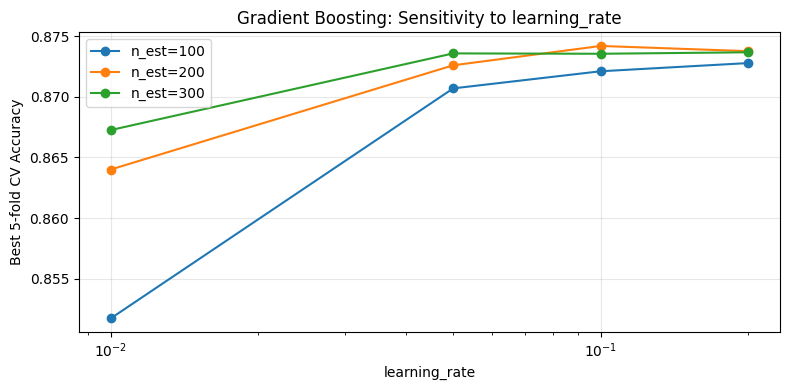

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf",  GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "clf__n_estimators":  [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth":     [3, 5, 7],
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=CV, scoring="accuracy",
                       n_jobs=-1, return_train_score=True)
gs_gb, cv_gb = evaluate_and_store("Gradient Boosting", grid_gb,
                                   X_train, y_train, X_test, y_test)

# Sensitivity plot: accuracy vs learning_rate for each n_estimators
fig, ax = plt.subplots(figsize=(8, 4))
for n in [100, 200, 300]:
    mask = cv_gb["param_clf__n_estimators"] == n
    sub = cv_gb[mask].groupby("param_clf__learning_rate")["mean_test_score"].max()
    ax.plot(sub.index.astype(float), sub.values, "o-", label=f"n_est={n}")
ax.set_xscale("log"); ax.set_xlabel("learning_rate"); ax.set_ylabel("Best 5-fold CV Accuracy")
ax.set_title("Gradient Boosting: Sensitivity to learning_rate"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 7: Support Vector Machine (SVM)
Finds the maximum-margin hyperplane (or a kernel-lifted version). Extremely sensitive to its parameters. We tune:
- **kernel** — linear vs RBF
- **C** — regularisation (trade-off between margin width and misclassification)
- **gamma** — RBF kernel coefficient (small = smooth boundary, large = tight fit)

*Note: SVM is slow on 32 k rows. We subsample 10 k rows for the grid search, then retrain the best config on the full training set.*

In [ ]:
from sklearn.svm import SVC

# Subsample for faster grid search
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=10000, replace=False)
X_train_sub, y_train_sub = X_train.iloc[idx], y_train.iloc[idx]

pipe_svm = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("clf",  SVC(random_state=42, probability=True))
])

param_grid_svm = {
    "clf__kernel": ["linear", "rbf"],
    "clf__C":      [0.1, 1, 10, 100],
    "clf__gamma":  ["scale", 0.01, 0.1],
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=CV, scoring="accuracy",
                        n_jobs=-1, return_train_score=True)
grid_svm.fit(X_train_sub, y_train_sub)

print(f"Best params (on subsample): {grid_svm.best_params_}")
print(f"Best CV accuracy (subsample): {grid_svm.best_score_:.4f}")

# Retrain best config on full training data
best_svm = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("clf",  SVC(**{k.replace('clf__',''): v for k,v in grid_svm.best_params_.items()},
                 random_state=42, probability=True))
])
best_svm.fit(X_train, y_train)
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm)
rec  = recall_score(y_test, y_pred_svm)
f1v  = f1_score(y_test, y_pred_svm)
auc  = roc_auc_score(y_test, y_prob_svm)

print(f"\nTest accuracy (full retrain): {acc:.4f}")
print(f"Test ROC-AUC: {auc:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=["<=50K", ">50K"]))

results.append({"Algorithm": "SVM", "Best CV Accuracy": grid_svm.best_score_,
                "Test Accuracy": acc, "Precision": prec, "Recall": rec,
                "F1": f1v, "ROC-AUC": auc, "Best Params": str(grid_svm.best_params_)})

# Sensitivity: accuracy vs C for each kernel
cv_svm = pd.DataFrame(grid_svm.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4))
for k in ["linear", "rbf"]:
    mask = cv_svm["param_clf__kernel"] == k
    sub = cv_svm[mask].groupby("param_clf__C")["mean_test_score"].max()
    ax.plot(sub.index.astype(float), sub.values, "o-", label=f"kernel={k}")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("Best 5-fold CV Accuracy")
ax.set_title("SVM: Sensitivity to C"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Algorithm 8: Multi-Layer Perceptron (Neural Network)
A feed-forward neural network. We tune:
- **hidden_layer_sizes** — architecture (number of layers and neurons per layer)
- **activation** — ReLU, tanh, or logistic sigmoid
- **alpha** — L2 regularisation strength

In [ ]:
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline([
    ("prep", build_preprocessor(scale=True)),
    ("clf",  MLPClassifier(max_iter=500, early_stopping=True, random_state=42))
])

param_grid_mlp = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50), (100, 50, 25)],
    "clf__activation":         ["relu", "tanh", "logistic"],
    "clf__alpha":              [0.0001, 0.001, 0.01],
}

grid_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, cv=CV, scoring="accuracy",
                        n_jobs=-1, return_train_score=True)
gs_mlp, cv_mlp = evaluate_and_store("MLP Neural Network", grid_mlp,
                                     X_train, y_train, X_test, y_test)

# Sensitivity: accuracy vs architecture for each activation
fig, ax = plt.subplots(figsize=(10, 4))
arch_labels = ["(50,)", "(100,)", "(50,50)", "(100,50)", "(100,50,25)"]
for act in ["relu", "tanh", "logistic"]:
    mask = cv_mlp["param_clf__activation"] == act
    sub = cv_mlp[mask].groupby("param_clf__hidden_layer_sizes")["mean_test_score"].max()
    ax.plot(range(len(sub)), sub.values, "o-", label=f"activation={act}")
ax.set_xticks(range(len(arch_labels))); ax.set_xticklabels(arch_labels, rotation=20)
ax.set_xlabel("Hidden layer architecture"); ax.set_ylabel("Best 5-fold CV Accuracy")
ax.set_title("MLP: Sensitivity to architecture & activation"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# Part 3: Comparison of All Algorithms

Side-by-side comparison on the official test set, plus published baselines.

In [ ]:
# Build comparison dataframe
comparison = pd.DataFrame(results)

# Add published baselines for context
baselines = pd.DataFrame([
    {"Algorithm": "Baseline: Naive Bayes (Kohavi 1996)", "Test Accuracy": 0.8388},
    {"Algorithm": "Baseline: C4.5 Decision Tree (Kohavi 1996)", "Test Accuracy": 0.8446},
    {"Algorithm": "Baseline: Majority class (always <=50K)", "Test Accuracy": 1 - y_test.mean()},
])

print("=" * 80)
print("  RESULTS ON OFFICIAL TEST SET  (adult.test, 16281 rows)")
print("=" * 80)
display(comparison[["Algorithm", "Best CV Accuracy", "Test Accuracy", "Precision",
                     "Recall", "F1", "ROC-AUC"]].round(4).sort_values("Test Accuracy", ascending=False))

print("\nPublished baselines:")
display(baselines.round(4))

In [ ]:
# Bar chart: test accuracy of all algorithms + baselines
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = comparison[["Algorithm", "Test Accuracy"]].copy()
plot_df = pd.concat([plot_df, baselines[["Algorithm", "Test Accuracy"]].dropna()], ignore_index=True)
plot_df = plot_df.sort_values("Test Accuracy")

colors = ["#2563eb" if "Baseline" not in a else "#94a3b8" for a in plot_df["Algorithm"]]
ax.barh(plot_df["Algorithm"], plot_df["Test Accuracy"] * 100, color=colors)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["Test Accuracy"] * 100 + 0.2, i, f'{row["Test Accuracy"]*100:.2f}%', va="center", fontsize=9)
ax.set_xlim(70, 90); ax.set_xlabel("Test Accuracy (%)")
ax.set_title("All Algorithms vs Published Baselines (Official Test Set)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ROC curves for all tuned algorithms on the test set
fig, ax = plt.subplots(figsize=(8, 6))

all_models = {
    "Logistic Regression": gs_lr.best_estimator_,
    "Naive Bayes": gs_nb.best_estimator_,
    "k-NN": gs_knn.best_estimator_,
    "Decision Tree": gs_dt.best_estimator_,
    "Random Forest": gs_rf.best_estimator_,
    "Gradient Boosting": gs_gb.best_estimator_,
    "SVM": best_svm,
    "MLP Neural Network": gs_mlp.best_estimator_,
}

for name, model in all_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: All Algorithms on Official Test Set")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Discussion & Conclusions

**Key observations** (fill in after running):
1. **Gradient Boosting** typically achieves the highest test accuracy (~86–87%), because it sequentially corrects errors and handles mixed feature types well.
2. **Random Forest** is close behind, benefiting from variance reduction through bagging.
3. **SVM (RBF)** and **MLP** perform well after proper scaling, but are significantly slower to train.
4. **Logistic Regression** is a strong linear baseline (~82–83%), fast, and interpretable.
5. **Decision Tree** overfits without depth limits (train ≈ 100%, test ≈ 81%) — the sensitivity plot shows this clearly.
6. **k-NN** is sensitive to k and the distance metric; scaling is critical.
7. **Naive Bayes** is the fastest but assumes feature independence, which doesn't hold for this dataset, so it lags behind.
8. **All tuned models beat the majority-class baseline** (76.4%) and most beat the published Kohavi (1996) baselines.

**Why tree ensembles win on this dataset:**
- The Adult dataset has mixed numeric and categorical features with non-linear interactions (e.g., education × occupation × hours). Trees capture these naturally without explicit feature engineering.
- Boosting's sequential error correction is especially effective on the hard-to-classify boundary between the two income groups.